<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec10_mlp_digit_number_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP를 이용한 손글씨 숫자 인식 (학생용)

이 실습에서는 **Multi-Layer Perceptron(MLP)** 을 NumPy로 직접 구현하여 MNIST 손글씨 숫자를 분류합니다.  
라이브러리 없이 수식을 직접 코드로 옮기며 딥러닝의 핵심 원리를 이해합니다.

**학습 목표:**
1. 활성화 함수 (Sigmoid, ReLU, Softmax) 수식 이해 및 구현
2. Forward Propagation 수식 이해 및 구현
3. Back Propagation (역전파) 수식 이해 및 구현
4. Mini-batch Gradient Descent를 이용한 학습

---
**학번:** 2023042028\
**이름:** 권택주

In [1]:
#@title { vertical-output: true }
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

---
## Part 1: 데이터셋 로드 및 시각화

**MNIST 데이터셋**: 손글씨 숫자 이미지 70,000장 (0~9)
- 각 이미지: 28×28 픽셀 = **784개 특성**
- 클래스: 0, 1, 2, ..., 9 (**10개 클래스**)

---

In [2]:
#@title { vertical-output: true }
# MNIST 데이터셋 로드
mnist = fetch_openml('mnist_784')
X, y = mnist['data'].to_numpy(), mnist['target'].to_numpy().astype(int)

print(f"데이터 크기: {X.shape}")
print(f"레이블 크기: {y.shape}")
print(f"픽셀 값 범위: [{X.min()}, {X.max()}]")
print(f"클래스: {np.unique(y)}")

데이터 크기: (70000, 784)
레이블 크기: (70000,)
픽셀 값 범위: [0, 255]
클래스: [0 1 2 3 4 5 6 7 8 9]


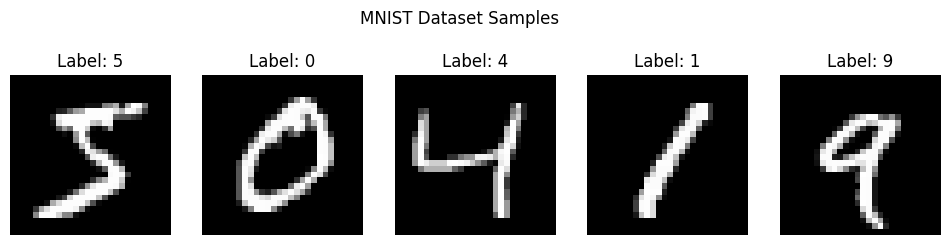

In [3]:
#@title { vertical-output: true }
# 샘플 이미지 시각화
num_imgs = 5
fig, axes = plt.subplots(1, num_imgs, figsize=(12, 3))
for i in range(num_imgs):
    axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')
plt.suptitle('MNIST Dataset Samples')
plt.show()

---
## Part 2: 데이터 전처리

**전처리 과정:**

1. **One-Hot Encoding**: 레이블 → 벡터 변환
   - 예: `3` → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`
   - 신경망의 출력(10차원)과 비교하기 위해 필요

2. **Train/Test Split**: 훈련(80%) / 테스트(20%) 분할

3. **Standardization**: 정규화 (평균=0, 표준편차=1)
   - 픽셀 값 [0, 255] → 표준화된 값
   - 학습 안정성 향상

---

In [4]:
#@title { vertical-output: true }
# One-Hot Encoding
y_ohe = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
print(f"One-Hot 변환 전: y[0] = {y[0]}")
print(f"One-Hot 변환 후: y_ohe[0] = {y_ohe[0]}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_ohe, test_size=0.2, random_state=12)
print(f"\n훈련 데이터: {X_train.shape[0]}개")
print(f"테스트 데이터: {X_test.shape[0]}개")

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"\n정규화 후 X_train 평균: {X_train.mean():.4f}")
print(f"정규화 후 X_train 표준편차: {X_train.std():.4f}")

One-Hot 변환 전: y[0] = 5
One-Hot 변환 후: y_ohe[0] = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

훈련 데이터: 56000개
테스트 데이터: 14000개

정규화 후 X_train 평균: -0.0000
정규화 후 X_train 표준편차: 0.9563


---
## Part 3: 활성화 함수 구현 (20점)

### 활성화 함수가 왜 필요한가?

활성화 함수 없이 여러 층을 쌓으면 결국 하나의 선형 변환과 동일합니다:

$$W_2(W_1 x + b_1) + b_2 = \underbrace{(W_2 W_1)}_{W'} x + \underbrace{(W_2 b_1 + b_2)}_{b'} \quad \Rightarrow \text{여전히 선형!}$$

활성화 함수를 통해 **비선형성**을 추가해야 복잡한 패턴을 학습할 수 있습니다.

---

### 문제 3-1. Sigmoid 함수 구현 [5점]

#### 수식

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

#### 특성
- **출력 범위**: $(0, 1)$ → 확률처럼 해석 가능
- **S자 곡선**: 입력이 매우 크면 1에 수렴, 매우 작으면 0에 수렴
- **미분 가능**: 역전파에서 사용

#### Sigmoid 미분 유도

역전파(Back Propagation)에서 활성화 함수의 미분이 필요합니다.

$$\frac{d\sigma}{dx} = \frac{d}{dx}\left(\frac{1}{1+e^{-x}}\right)$$

$u = 1 + e^{-x}$로 놓으면:

$$\frac{d\sigma}{dx} = -\frac{u'}{u^2} = \frac{e^{-x}}{(1+e^{-x})^2}$$

이를 $\sigma(x)$로 변환합니다:

$$= \frac{1}{1+e^{-x}} \cdot \frac{e^{-x}}{1+e^{-x}} = \sigma(x) \cdot \frac{(1+e^{-x})-1}{1+e^{-x}} = \sigma(x) \cdot (1 - \sigma(x))$$

따라서:

$$\boxed{\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))}$$

> **코드 주의**: `sigmoid_prime(x)`의 입력 `x`는 이미 sigmoid를 적용한 값 $\sigma(z)$입니다.  
> 따라서 함수 내부에서 `return x * (1 - x)`로 구현합니다.

#### 수치 안정성
`np.exp(x)`에서 $x$가 매우 크면 overflow가 발생합니다.  
`np.clip(x, -100, 100)`으로 입력값을 제한하여 안정성을 확보합니다.

#### 예상 결과
```
sigmoid(0)          → 0.5
sigmoid(0.7)        → 0.66818...
sigmoid_prime(0.7)  → 0.7 * (1 - 0.7) = 0.21
```

In [14]:
#@title { vertical-output: true }
def sigmoid(x):
    """
    Sigmoid 활성화 함수
    수식: sigma(x) = 1 / (1 + exp(-x))

    구현 순서:
    1. np.clip으로 x를 [-100, 100] 범위로 제한 (수치 안정성)
    2. 수식을 그대로 구현
    """
    # IMPLEMENT HERE
    x = np.clip(x, -100, 100)
    result = 1 / (1 + np.exp(-x))
    return result

def sigmoid_prime(x):
    """
    Sigmoid 미분
    수식: sigma'(x) = sigma(x) * (1 - sigma(x))

    주의: 입력 x는 이미 sigmoid를 통과한 값 sigma(z)입니다.
    따라서 return x * (1 - x)로 구현합니다.
    """
    # IMPLEMENT HERE
    pass
    return x * (1 - x)


# 검증 (모두 통과해야 합니다)
assert sigmoid(0) == 0.5, "sigmoid(0)은 0.5여야 합니다"
assert abs(sigmoid(0.7) - 0.66818) < 0.00001, "sigmoid(0.7) 값을 확인하세요"
assert abs(sigmoid_prime(0.7) - 0.21) < 0.00001, "sigmoid_prime(0.7) 값을 확인하세요"
print("✓ Sigmoid 테스트 통과!")
print(f"  sigmoid(0)   = {sigmoid(0)}")
print(f"  sigmoid(0.7) = {sigmoid(0.7):.5f}")

✓ Sigmoid 테스트 통과!
  sigmoid(0)   = 0.5
  sigmoid(0.7) = 0.66819


### 문제 3-2. ReLU 함수 구현 [5점]

#### 수식

$$\text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{if } x > 0 \\ 0 & \text{otherwise} \end{cases}$$

#### 특성
- **단순함**: 계산이 빠름
- **Vanishing Gradient 완화**: 양수 구간에서 그래디언트가 그대로 전달 (sigmoid와 달리 1)
- **희소 활성화**: 음수 입력은 0으로 → 네트워크의 효율적인 표현 학습

#### ReLU 미분

$$\text{ReLU}'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{otherwise} \end{cases}$$

> **주의**: $x = 0$에서 미분이 정의되지 않지만, 실용적으로 0으로 처리합니다.

#### NumPy 구현 힌트
- `np.maximum(a, b)`: 원소별 최댓값 (스칼라 max와 다름!)
- `(x > 0).astype(float)`: 조건을 float 배열로 변환

#### 예상 결과
```
relu(1)                          → 1
relu(-2)                         → 0
relu_prime([0.7, -0.6])          → [1.0, 0.0]
```

In [15]:
#@title { vertical-output: true }
def relu(x):
    """
    ReLU 활성화 함수
    수식: ReLU(x) = max(0, x)
    """
    # IMPLEMENT HERE
    return np.maximum(0, x)

def relu_prime(x):
    """
    ReLU 미분
    수식: 1 if x > 0 else 0

    힌트: (x > 0)은 True/False 배열 → .astype(float)으로 0.0/1.0 변환
    """
    # IMPLEMENT HERE
    return (x > 0).astype(float)

# 검증
assert relu(1) == 1
assert relu(-2) == 0
assert np.array_equal(relu_prime(np.array([0.7, -0.6])), np.array([1.0, 0.0]))
print("✓ ReLU 테스트 통과!")
print(f"  relu([-2, -1, 0, 1, 2]) = {relu(np.array([-2, -1, 0, 1, 2]))}")

✓ ReLU 테스트 통과!
  relu([-2, -1, 0, 1, 2]) = [0 0 0 1 2]


### 문제 3-3. Softmax 함수 구현 [10점]

#### 수식

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{K} e^{x_j}}, \quad i = 1, 2, \ldots, K$$

#### 특성
1. **확률 분포**: 모든 출력의 합 = 1, 즉 $\sum_{i=1}^{K} \text{softmax}(x_i) = 1$
2. **양수 보장**: 모든 출력 > 0 (지수 함수 사용)
3. **순서 보존**: 입력이 크면 확률도 높음

#### 왜 Softmax를 마지막 층에 사용하는가?

MNIST는 10개 클래스(0~9) 중 하나를 예측합니다.  
신경망의 마지막 출력(logits) $z_3$을 **확률 분포**로 변환합니다:

$$z_3 = [2.1,\ 0.5,\ 8.3,\ \ldots] \xrightarrow{\text{softmax}} [0.02,\ 0.005,\ 0.75,\ \ldots]$$

가장 높은 확률의 인덱스가 예측 클래스가 됩니다.

#### 수치 안정성 트릭

$e^{x_i}$에서 $x_i$가 크면 **overflow** 발생!  
해결: 각 입력에서 최댓값 $c = \max(x)$를 빼줍니다:

$$\text{softmax}(x_i) = \frac{e^{x_i - c}}{\sum_{j=1}^{K} e^{x_j - c}}$$

**왜 동일한가?**

$$\frac{e^{x_i - c}}{\sum_j e^{x_j - c}} = \frac{e^{x_i} \cdot e^{-c}}{\sum_j e^{x_j} \cdot e^{-c}} = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

#### 배치 처리 (중요!)

$m$개 샘플을 동시에 처리합니다. 각 샘플은 **독립적으로** softmax를 적용해야 합니다:
- `np.max(x, axis=1, keepdims=True)`: 각 샘플(행)의 최댓값 → shape: $(m, 1)$
- `np.sum(..., axis=1, keepdims=True)`: 각 샘플(행)의 합 → shape: $(m, 1)$
- `keepdims=True`: 브로드캐스팅을 위해 차원 유지

#### 예상 결과
```
softmax([[1.0, 2.0, 3.0]]) → [[0.0900, 0.2447, 0.6652]]
출력의 합                  → 1.0
```

In [16]:
#@title { vertical-output: true }
def softmax(x):
    """
    Softmax 활성화 함수 (배치 처리)
    수식: softmax(x_i) = exp(x_i) / sum(exp(x_j))

    구현 순서:
    1. 수치 안정성을 위해 각 행에서 최댓값을 뺀다 (keepdims=True 필수!)
    2. exp를 적용한다
    3. 각 행의 합으로 나눈다 (keepdims=True 필수!)

    Parameters:
        x: 입력 배열, shape (m, K) - m개 샘플, K개 클래스
    Returns:
        확률 분포, shape (m, K)
    """
    # IMPLEMENT HERE
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# 검증
test_input = np.array([[1.0, 2.0, 3.0]])
expected = np.array([[0.09003057, 0.24472847, 0.66524096]])
assert np.allclose(softmax(test_input), expected, atol=1e-5)
print("✓ Softmax 테스트 통과!")
print(f"  입력: {test_input}")
print(f"  출력: {softmax(test_input)}")
print(f"  출력 합계: {np.sum(softmax(test_input)):.6f}  ← 반드시 1.0이어야 합니다")

✓ Softmax 테스트 통과!
  입력: [[1. 2. 3.]]
  출력: [[0.09003057 0.24472847 0.66524096]]
  출력 합계: 1.000000  ← 반드시 1.0이어야 합니다


---
## Part 4: Forward Propagation 구현 (30점)

### 네트워크 구조

```
  입력층          은닉층 1         은닉층 2         출력층
  (784)    W1     (128)    W2      (64)    W3      (10)
    X   ──────►   z1   ──────►   z2   ──────►   z3
         + b1   [ReLU]   + b2   [ReLU]   + b3  [Softmax]
                 = h1             = h2            = ŷ
```

### Forward Propagation이란?

입력 데이터 $X$를 받아 각 층을 **순서대로** 통과시켜 최종 예측값 $\hat{y}$를 계산하는 과정입니다.

각 층은 두 단계로 구성됩니다:
1. **선형 변환**: $z = X \cdot W + b$ (가중치와 편향으로 새로운 표현 생성)
2. **비선형 활성화**: $h = f(z)$ (비선형성 추가로 복잡한 패턴 학습)

---
### 수식 (배치 크기 $m$)

$m$개의 샘플을 한 번에 처리합니다 (행렬 연산).

**Layer 1 — Input → Hidden1:**

$$z_1 = X \cdot W_1 + b_1$$

$$\underbrace{(m \times 784)}_{X} \cdot \underbrace{(784 \times 128)}_{W_1} + \underbrace{(1 \times 128)}_{b_1} = \underbrace{(m \times 128)}_{z_1}$$

$$h_1 = \text{ReLU}(z_1) \quad \text{shape: } (m, 128)$$

---
**Layer 2 — Hidden1 → Hidden2:**

$$z_2 = h_1 \cdot W_2 + b_2$$

$$\underbrace{(m \times 128)}_{h_1} \cdot \underbrace{(128 \times 64)}_{W_2} + \underbrace{(1 \times 64)}_{b_2} = \underbrace{(m \times 64)}_{z_2}$$

$$h_2 = \text{ReLU}(z_2) \quad \text{shape: } (m, 64)$$

---
**Layer 3 — Hidden2 → Output:**

$$z_3 = h_2 \cdot W_3 + b_3$$

$$\underbrace{(m \times 64)}_{h_2} \cdot \underbrace{(64 \times 10)}_{W_3} + \underbrace{(1 \times 10)}_{b_3} = \underbrace{(m \times 10)}_{z_3}$$

$$\hat{y} = \text{softmax}(z_3) \quad \text{shape: } (m, 10)$$

---


### NumPy 행렬 곱셈

```python
A @ B          # Python 3.5+ 행렬 곱셈 연산자
np.dot(A, B)   # 동일한 결과
```

### 예상 결과
```
y_hat.shape        → (5, 10)           # 5개 샘플, 10개 클래스
y_hat.sum(axis=1)  → [1.0, 1.0, ...]  # 각 행의 합 = 1 (확률 분포)
```

In [18]:
#@title { vertical-output: true }
np.random.seed(42)

w1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
b1 = np.zeros((1, 128))

w2 = np.random.randn(128, 64) * np.sqrt(2 / 128)
b2 = np.zeros((1, 64))

w3 = np.random.randn(64, 10) * np.sqrt(2 / 64)
b3 = np.zeros((1, 10))
def forward_prop(w1, w2, w3, b1, b2, b3, x):
    """
    Forward Propagation

    Parameters:
        w1 (784, 128), w2 (128, 64), w3 (64, 10): 각 레이어의 가중치
        b1 (1, 128), b2 (1, 64), b3 (1, 10): 각 레이어의 편향
        x (m, 784): 입력 데이터

    Returns:
        z1, h1 (m, 128): Layer 1의 선형 출력, 활성화 출력
        z2, h2 (m, 64) : Layer 2의 선형 출력, 활성화 출력
        z3     (m, 10) : Layer 3의 선형 출력
        y_hat  (m, 10) : 최종 예측 확률 (softmax 출력)
    """
    # IMPLEMENT HERE
    # Layer 1: Input → Hidden1
    # z1 = ...    (선형 변환: x @ w1 + b1)
    # h1 = ...    (활성화: ReLU 적용)

    # Layer 2: Hidden1 → Hidden2
    # z2 = ...    (선형 변환: h1 @ w2 + b2)
    # h2 = ...    (활성화: ReLU 적용)

    # Layer 3: Hidden2 → Output
    # z3 = ...    (선형 변환: h2 @ w3 + b3)
    # y_hat = ... (활성화: Softmax 적용)

    z1 = x @ w1 + b1
    h1 = relu(z1)

    z2 = h1 @ w2 + b2
    h2 = relu(z2)

    z3 = h2 @ w3 + b3
    y_hat = softmax(z3)

    return z1, h1, z2, h2, z3, y_hat

# 구현 후 아래 검증 코드를 실행하세요
# (가중치 초기화 이전에는 실행 불가 - Part 6 이후 실행)
z1, h1, z2, h2, z3, y_hat = forward_prop(w1, w2, w3, b1, b2, b3, X_train[:5])
print(f"y_hat.shape: {y_hat.shape}")        # (5, 10)
print(f"y_hat.sum(axis=1): {y_hat.sum(axis=1)}")  # 모두 1.0
print("forward_prop 함수 정의 완료")

y_hat.shape: (5, 10)
y_hat.sum(axis=1): [1. 1. 1. 1. 1.]
forward_prop 함수 정의 완료


---
## Part 5: Back Propagation 구현 (30점)

### 손실 함수: Cross-Entropy Loss

다중 분류에서 사용하는 손실 함수입니다:

$$L = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

- $m$: 배치 크기
- $K$: 클래스 수 (10)
- $y_{ik}$: 실제 레이블 (one-hot, 0 또는 1)
- $\hat{y}_{ik}$: 예측 확률

### Back Propagation의 원리

**목표**: 각 파라미터가 손실 $L$에 미치는 영향(그래디언트)을 계산합니다.

$$W \leftarrow W - \alpha \cdot \frac{\partial L}{\partial W}$$

**핵심: 연쇄 법칙 (Chain Rule)**

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$$

출력층 → 은닉층 방향으로 **역방향으로** 그래디언트를 전파합니다.

---
### Step 1: 출력층 그래디언트

**Softmax + Cross-Entropy 결합 그래디언트 (핵심 결과!):**

$$\boxed{\frac{\partial L}{\partial z_3} = \hat{y} - y} \quad \text{shape: } (m, 10)$$

**직관**: 예측이 정답과 같으면 그래디언트 = 0 (업데이트 없음)  
예측이 틀리면 차이만큼 그래디언트 발생 → 올바른 방향으로 업데이트

**가중치 그래디언트:**

$$\frac{\partial L}{\partial W_3} = \frac{1}{m} h_2^T \cdot \frac{\partial L}{\partial z_3} \quad \text{shape: } (64, 10)$$

$$\frac{\partial L}{\partial b_3} = \frac{1}{m} \mathbf{1}^T \cdot \frac{\partial L}{\partial z_3} \quad \text{shape: } (1, 10)$$

여기서 $\mathbf{1}$은 shape $(1, m)$인 ones 벡터 → 배치 평균 계산

---
### Step 2: Hidden Layer 2 그래디언트

그래디언트 흐름: $z_3 \leftarrow h_2 \leftarrow z_2$

$$\frac{\partial L}{\partial h_2} = \frac{\partial L}{\partial z_3} \cdot W_3^T \quad \text{shape: } (m, 64)$$

ReLU 미분을 통해 $z_2$까지 전파:

$$\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial h_2} \odot \text{ReLU}'(z_2) \quad \text{shape: } (m, 64)$$

> $\odot$: 원소별 곱셈 (Hadamard product)  
> ReLU'는 $z_2 > 0$이면 1, 아니면 0 → 음수 구간의 그래디언트는 소멸

$$\frac{\partial L}{\partial W_2} = \frac{1}{m} h_1^T \cdot \frac{\partial L}{\partial z_2} \quad \text{shape: } (128, 64)$$

$$\frac{\partial L}{\partial b_2} = \frac{1}{m} \mathbf{1}^T \cdot \frac{\partial L}{\partial z_2} \quad \text{shape: } (1, 64)$$

---
### Step 3: Hidden Layer 1 그래디언트

같은 방식을 반복합니다:

$$\frac{\partial L}{\partial z_1} = \left(\frac{\partial L}{\partial z_2} \cdot W_2^T\right) \odot \text{ReLU}'(z_1) \quad \text{shape: } (m, 128)$$

$$\frac{\partial L}{\partial W_1} = \frac{1}{m} X^T \cdot \frac{\partial L}{\partial z_1} \quad \text{shape: } (784, 128)$$

$$\frac{\partial L}{\partial b_1} = \frac{1}{m} \mathbf{1}^T \cdot \frac{\partial L}{\partial z_1} \quad \text{shape: } (1, 128)$$

---
### 구현 패턴 요약

각 레이어의 패턴이 동일합니다:

```python
dz = (이전_dz @ 다음_W.T) * relu_prime(z)   # 그래디언트 전파 + ReLU 미분
dW = 이전_h.T @ dz / m                       # 가중치 그래디언트
db = np.ones((1, m)) @ dz / m                # 편향 그래디언트
```

In [19]:
#@title { vertical-output: true }
def back_prop(m, w1, w2, w3, z1, h1, z2, h2, y_hat, x, y):
    """
    Back Propagation

    Parameters:
        m: 배치 크기
        w1, w2, w3: 각 레이어의 가중치 (역전파에서 사용)
        z1 (m,128), h1 (m,128): Layer 1의 선형/활성화 출력
        z2 (m,64),  h2 (m,64) : Layer 2의 선형/활성화 출력
        y_hat (m,10): 예측값
        x (m,784): 입력 데이터
        y (m,10): 실제 레이블 (one-hot)

    Returns:
        dw1, db1, dw2, db2, dw3, db3: 각 파라미터의 그래디언트
    """
    # IMPLEMENT HERE

    # Step 1: 출력층 그래디언트
    # dz3 = ...   (핵심 공식: y_hat - y)
    # dw3 = ...   (h2.T @ dz3 / m)
    # db3 = ...   (np.ones((1, m)) @ dz3 / m)

    # Step 2: Hidden Layer 2 그래디언트
    # dz2 = ...   ((dz3 @ w3.T) * relu_prime(z2))
    # dw2 = ...   (h1.T @ dz2 / m)
    # db2 = ...   (np.ones((1, m)) @ dz2 / m)

    # Step 3: Hidden Layer 1 그래디언트
    # dz1 = ...   ((dz2 @ w2.T) * relu_prime(z1))
    # dw1 = ...   (x.T @ dz1 / m)
    # db1 = ...   (np.ones((1, m)) @ dz1 / m)

    dz3 = y_hat - y
    dw3 = h2.T @ dz3 / m
    db3 = np.ones((1, m)) @ dz3 / m

    # Step 2: Hidden Layer 2 그래디언트
    dz2 = (dz3 @ w3.T) * relu_prime(z2)
    dw2 = h1.T @ dz2 / m
    db2 = np.ones((1, m)) @ dz2 / m

    # Step 3: Hidden Layer 1 그래디언트
    dz1 = (dz2 @ w2.T) * relu_prime(z1)
    dw1 = x.T @ dz1 / m
    db1 = np.ones((1, m)) @ dz1 / m

    return dw1, db1, dw2, db2, dw3, db3

print("back_prop 함수 정의 완료")

back_prop 함수 정의 완료


---
## Part 6: 가중치 초기화 구현 (10점)

### 왜 초기화가 중요한가?

- **모두 0으로 초기화**: 모든 뉴런이 같은 그래디언트를 받아 동일하게 업데이트 → **대칭성 문제**
- **너무 큰 값**: 활성화 함수 포화 → **그래디언트 소실 (Vanishing Gradient)**
- **너무 작은 값**: 신호 소실 → **학습 불가**

### He 초기화 (He Initialization)

ReLU 활성화 함수에 최적화된 초기화 방법입니다:

$$W \sim \mathcal{N}\left(0,\ \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

- $n_{\text{in}}$: 이전 레이어의 뉴런 수
- **원리**: ReLU가 절반의 뉴런을 0으로 만들기 때문에, 분산을 2배로 설정

**NumPy 구현:**
```python
w = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
```

### 네트워크 구조
- Input: 784 ($n_x$)
- Hidden1: 128 ($n_{h1}$)
- Hidden2: 64 ($n_{h2}$)
- Output: 10 ($n_y$)

### 문제 6-1. He 초기화 구현 [10점]

아래 빈칸을 채워 He 초기화를 구현하세요.

**예상 결과:**
```
W1 shape: (784, 128),  std ≈ 0.050
W2 shape: (128, 64),   std ≈ 0.125
W3 shape: (64, 10),    std ≈ 0.177
```

In [20]:
#@title { vertical-output: true }
np.random.seed(42)

# 네트워크 구조
n_x  = X_train.shape[1]   # 784
n_h1 = 128
n_h2 = 64
n_y  = y_train.shape[1]   # 10

# IMPLEMENT HERE
# He 초기화: W ~ N(0, sqrt(2/n_in))
# w1 = np.random.randn(?, ?) * np.sqrt(2.0 / ?)
# w2 = np.random.randn(?, ?) * np.sqrt(2.0 / ?)
# w3 = np.random.randn(?, ?) * np.sqrt(2.0 / ?)
# b1 = np.random.randn(1, n_h1)
# b2 = np.random.randn(1, n_h2)
# b3 = np.random.randn(1, n_y)

print(f"W1 shape: {w1.shape},  std: {w1.std():.4f}")
print(f"W2 shape: {w2.shape},  std: {w2.std():.4f}")
print(f"W3 shape: {w3.shape},  std: {w3.std():.4f}")

W1 shape: (784, 128),  std: 0.0506
W2 shape: (128, 64),  std: 0.1246
W3 shape: (64, 10),  std: 0.1724


---
## Part 7: 학습 루프 완성 (10점)

### Gradient Descent 업데이트 규칙

$$W \leftarrow W - \alpha \cdot \frac{\partial L}{\partial W}$$
$$b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}$$

여기서 $\alpha$는 학습률(learning rate)입니다.

### Mini-batch Gradient Descent

전체 데이터를 한 번에 처리하면 메모리 부족 → 작은 배치(batch)로 나눠 학습합니다.

**학습 설정:**
- Learning rate ($\alpha$): 0.01
- Epochs: 50
- Batch size: 100

**예상 결과:** 약 96~97% 정확도 달성

In [21]:
#@title { vertical-output: true }
# 하이퍼파라미터
lr = 0.01
epochs = 50
batch_size = 100

test_accuracies = []

# 학습 루프
for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        # Mini-batch 추출
        x_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        m = x_batch.shape[0]

        # Forward Propagation
        z1, h1, z2, h2, z3, y_hat = forward_prop(w1, w2, w3, b1, b2, b3, x_batch)

        # Back Propagation
        dw1, db1, dw2, db2, dw3, db3 = back_prop(m, w1, w2, w3, z1, h1, z2, h2, y_hat, x_batch, y_batch)

        # Gradient Descent Update
        w1 -= lr * dw1
        b1 -= lr * db1
        w2 -= lr * dw2
        b2 -= lr * db2
        w3 -= lr * dw3
        b3 -= lr * db3

    # 에폭별 정확도 계산 (테스트 데이터)
    _, _, _, _, _, y_test_hat = forward_prop(w1, w2, w3, b1, b2, b3, X_test)
    predictions = np.argmax(y_test_hat, axis=1)
    labels = np.argmax(y_test, axis=1)
    accuracy = np.mean(predictions == labels)
    test_accuracies.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:2d}/{epochs},  Test Accuracy: {accuracy:.4f}')

Epoch 10/50,  Test Accuracy: 0.9564
Epoch 20/50,  Test Accuracy: 0.9637
Epoch 30/50,  Test Accuracy: 0.9670
Epoch 40/50,  Test Accuracy: 0.9676
Epoch 50/50,  Test Accuracy: 0.9686


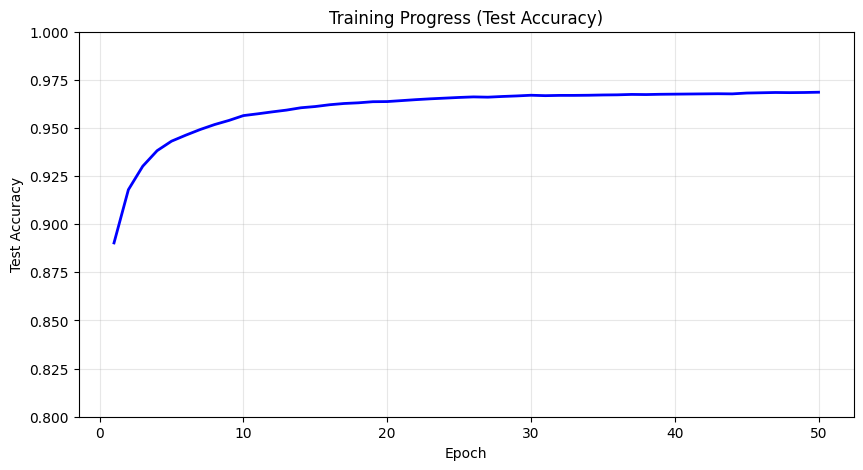

최종 테스트 정확도: 0.9686


In [22]:
#@title { vertical-output: true }
# 학습 곡선 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), test_accuracies, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Training Progress (Test Accuracy)')
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.0)
plt.show()

print(f"최종 테스트 정확도: {test_accuracies[-1]:.4f}")

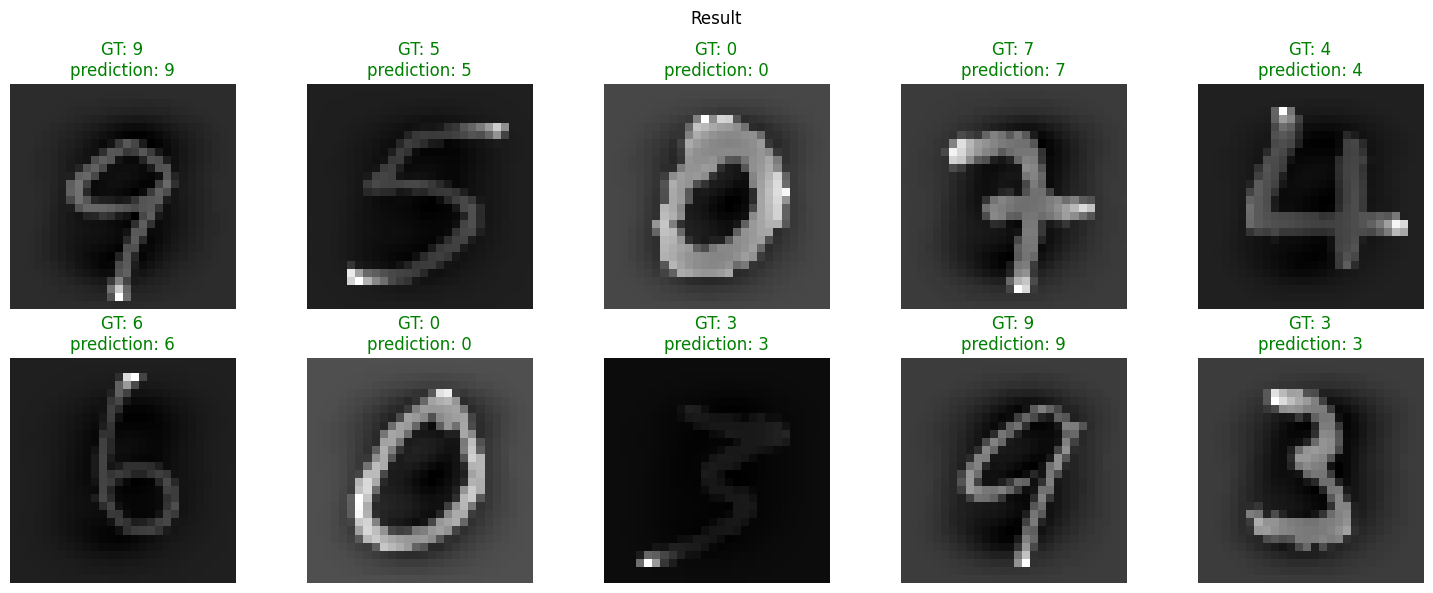

In [23]:
#@title { vertical-output: true }
# 예측 결과 시각화
_, _, _, _, _, y_test_hat = forward_prop(w1, w2, w3, b1, b2, b3, X_test)
y_pred = np.argmax(y_test_hat, axis=1)
y_true = np.argmax(y_test, axis=1)

num_imgs = 10
rand_imgs = np.random.randint(0, len(y_true), size=num_imgs)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for c, i in enumerate(rand_imgs):
    ax = axes[c // 5][c % 5]
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    ax.set_title(f"GT: {y_true[i]}\nprediction: {y_pred[i]}", color=color)
    ax.axis('off')
plt.suptitle('Result', fontsize=12)
plt.tight_layout()
plt.show()

---
## 제출 안내

### 제출 파일
1. **`.ipynb` 파일**: 모든 셀을 실행한 상태로 저장
2. **`.pdf` 파일**: 파일 → 인쇄 → PDF로 저장

### 파일명
```
mlp_digit_number_[학번]_[이름].ipynb
mlp_digit_number_[학번]_[이름].pdf
```

### 제출 체크리스트
- [x] Part 3-1: sigmoid, sigmoid_prime 구현 완료
- [x] Part 3-2: relu, relu_prime 구현 완료
- [x] Part 3-3: softmax 구현 완료
- [x] Part 4: forward_prop 구현 완료
- [x] Part 5: back_prop 구현 완료
- [x] Part 6: 가중치 초기화 구현 완료
- [x] Part 7: 학습 결과 확인 (정확도 ~96% 이상)
- [x] 모든 assert 통과 확인
- [x] .ipynb와 .pdf 모두 제출

### LMS 제출
두 파일을 **기한 내에** LMS에 제출하세요.  
> ⚠️ **기한 내에 제출하지 않으면 감점이 있습니다.**

---